# Figs. 2–3 and S1: paired CITE-seq

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/reproducibility/api/fig2_3_citeseq.ipynb)

The paired RNA + protein analysis of the Genome Research article (Figs. 2–3, Supplemental Fig. S1), run through UniVI's public API: `univi.datasets` for the data, fitted preprocessors, `UniVITrainer`, and `univi.evaluation`. Model settings are those of the archived notebook `UniVI_manuscript_GR-Figure__3__CITE_paired_biological_latent.ipynb` (summarized in Supplemental Table S8). Preprocessing follows Supplemental Table S7 using UniVI's preprocessors rather than the archived notebook's own code, so results will be close to, but not identical with, the published numbers. For the published numbers themselves, run the archived notebook with UniVI 0.4.7.

Data: Hao et al. (2021) PBMC CITE-seq, 161,764 cells with RNA and 228 surface proteins.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import (compute_modality_mixing, cross_modal_predict, encode_adata, evaluate_alignment,
                              pearson_corr_per_feature)
from univi.preprocessing import ADTPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 3000        # archived notebook: 3000 with early stopping (patience 100)
N_HVG = 2000
MAX_TEST_CELLS = 20000  # subsample the (large) test set for metrics and plots; None = all

## Data and split

The hosted files carry the split used in the article in `obs["split"]`. Otherwise the split is rebuilt the same way: stratified by `celltype.l3`, at most 1,200 cells per type in the train/validation pool (80/10), all remaining cells in test.

In [4]:
data = uds.hao_citeseq_pbmc()
rna, adt = data["rna"], data["adt"]
if "split" in rna.obs:
    splits = {k: np.flatnonzero(rna.obs["split"].to_numpy() == k) for k in ("train", "val", "test")}
else:
    splits = split_by_label(rna.obs["celltype.l3"], train_fraction=0.8, val_fraction=0.1, max_per_label=1200, seed=42)
print({k: len(v) for k, v in splits.items()})

hao_citeseq_pbmc_rna.h5ad: 100%|██████████| 749M/749M [04:08<00:00, 3.01MB/s] 
hao_citeseq_pbmc_adt.h5ad: 100%|██████████| 49.9M/49.9M [00:25<00:00, 1.94MB/s]


{'train': 37862, 'val': 4722, 'test': 119180}


## Preprocessing (fit on training cells)

RNA: 2,000 Seurat-v3 HVGs, library-size normalization to 10⁴, log1p, z-scores. Protein: per-cell CLR, z-scores.

In [5]:
rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[splits["train"]])
adt_prep = ADTPreprocessor(scale=True).fit(adt[splits["train"]])
parts = {k: {"rna": rna_prep.transform(rna[i]), "adt": adt_prep.transform(adt[i])} for k, i in splits.items()}

## Model and training

In [6]:
cfg = UniVIConfig(
    latent_dim=30, beta=1.5, gamma=5.0, encoder_dropout=0.1, decoder_dropout=0.0,
    kl_anneal_start=0, kl_anneal_end=0, align_anneal_start=0, align_anneal_end=0,
    modalities=[
        ModalityConfig("rna", parts["train"]["rna"].n_vars, [512, 256, 128], [128, 256, 512], likelihood="gaussian"),
        ModalityConfig("adt", parts["train"]["adt"].n_vars, [128, 64], [64, 128], likelihood="gaussian"),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(
    model, make_loader(parts["train"], batch_size=256, shuffle=True, drop_last=True),
    make_loader(parts["val"], batch_size=1024),
    TrainingConfig(n_epochs=N_EPOCHS, batch_size=256, lr=1e-3, weight_decay=1e-4, device=device,
                   early_stopping=True, patience=100, log_every=50),
).fit();

[2026-09-21 16:12:49,111] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-21 16:12:49,112] [UniVITrainer] [INFO]   n_epochs: 3000
[2026-09-21 16:12:49,113] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-21 16:12:49,113] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-21 16:12:49,114] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-21 16:12:49,114] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-21 16:12:49,115] [UniVITrainer] [INFO]   log_every: 50
[2026-09-21 16:12:49,115] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-21 16:12:49,115] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-21 16:12:49,116] [UniVITrainer] [INFO]   seed: 0
[2026-09-21 16:12:49,116] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-21 16:12:49,116] [UniVITrainer] [INFO]   patience: 100
[2026-09-21 16:12:49,117] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-21 16:12:49,117] [UniVITrainer] [INFO]   best_epoch_warmup: 0
Training UniVI:   0%|          | 0/3000 [00:00<?, ?it/s][2026-09-21 16:12:54,371] [Un

## Latent alignment on held-out cells (Fig. 2)

In [7]:
test = parts["test"]
if MAX_TEST_CELLS is not None and test["rna"].n_obs > MAX_TEST_CELLS:
    keep = np.sort(np.random.default_rng(0).choice(test["rna"].n_obs, MAX_TEST_CELLS, replace=False))
    test = {m: a[keep].copy() for m, a in test.items()}
z_rna = encode_adata(model, test["rna"], modality="rna", device=device, latent="modality_mean")
z_adt = encode_adata(model, test["adt"], modality="adt", device=device, latent="modality_mean")

rows = {}
for level in ["celltype.l1", "celltype.l2"]:
    lab = test["rna"].obs[level].astype(str).to_numpy()
    m = evaluate_alignment(Z1=z_rna, Z2=z_adt, labels_source=lab, labels_target=lab, recall_ks=(1, 10, 50))
    rows[level] = {"FOSCTTM": m["foscttm_mean"], "Recall@1": m["recall_at_k"]["1"]["mean"],
                   "Recall@10": m["recall_at_k"]["10"]["mean"], "Recall@50": m["recall_at_k"]["50"]["mean"],
                   "label transfer acc (RNA to ADT)": m["label_transfer_acc"],
                   "macro-F1, worse direction": m["worst_direction_macro_f1"]}
mixing = compute_modality_mixing(np.vstack([z_rna, z_adt]), np.repeat(["rna", "adt"], len(z_rna)), k=20)
print(f"modality mixing (k=20): {mixing:.3f}")
pd.DataFrame(rows).round(3)

modality mixing (k=20): 0.319


,celltype.l1,celltype.l2
FOSCTTM,0.025,0.025
Recall@1,0.011,0.011
Recall@10,0.063,0.063
Recall@50,0.193,0.193
label transfer acc (RNA to ADT),0.993,0.951
"macro-F1, worse direction",0.971,0.571


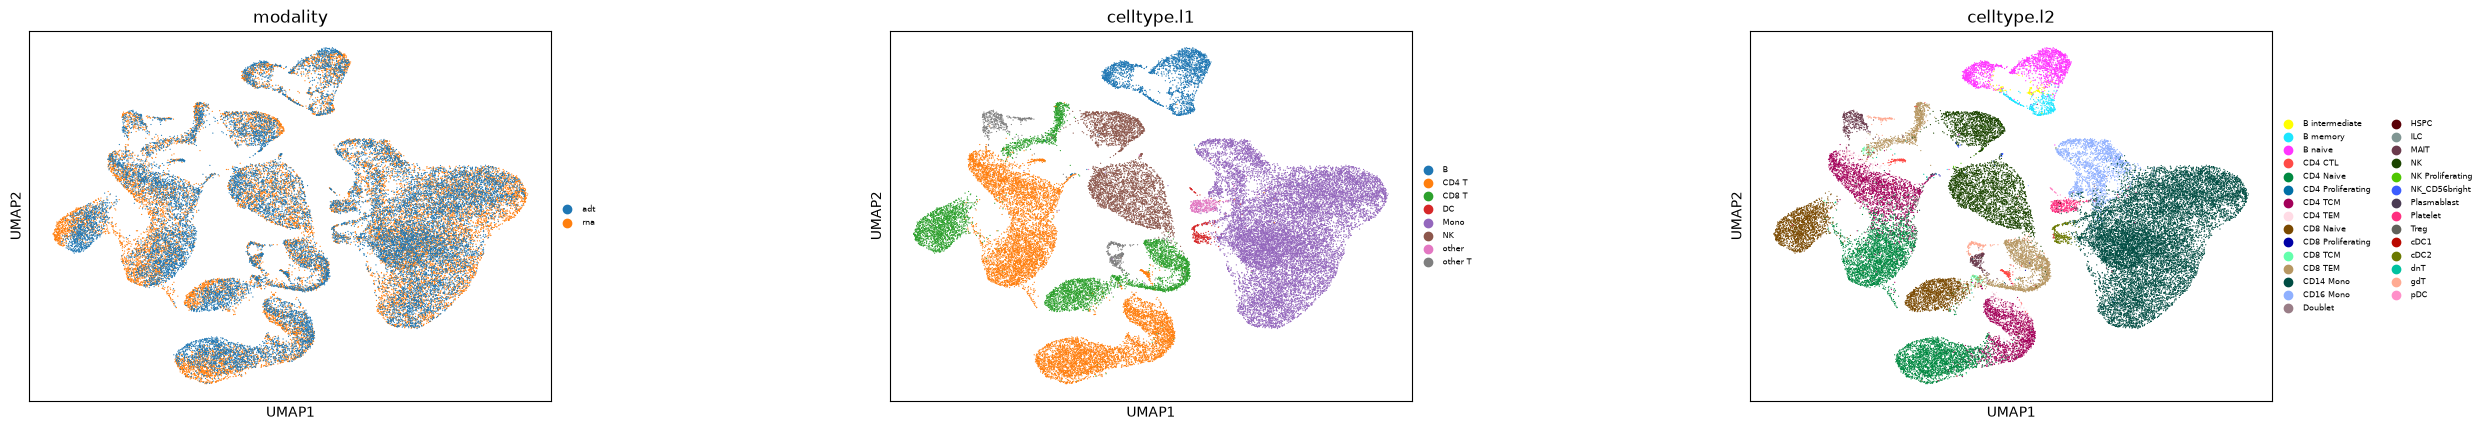

In [8]:
joint = stack_embeddings(model, [("test", "rna", test["rna"]), ("test", "adt", test["adt"])], device=device)
sc.pp.neighbors(joint, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(joint, random_state=0)
sc.pl.umap(joint, color=["modality", "celltype.l1", "celltype.l2"], wspace=0.5, legend_fontsize=6)

## Cross-modal reconstruction of markers (Fig. 3, Supplemental Fig. S1)

Protein predicted from RNA and RNA predicted from protein, shown on the reference UMAP of the RNA embedding next to the observed values.

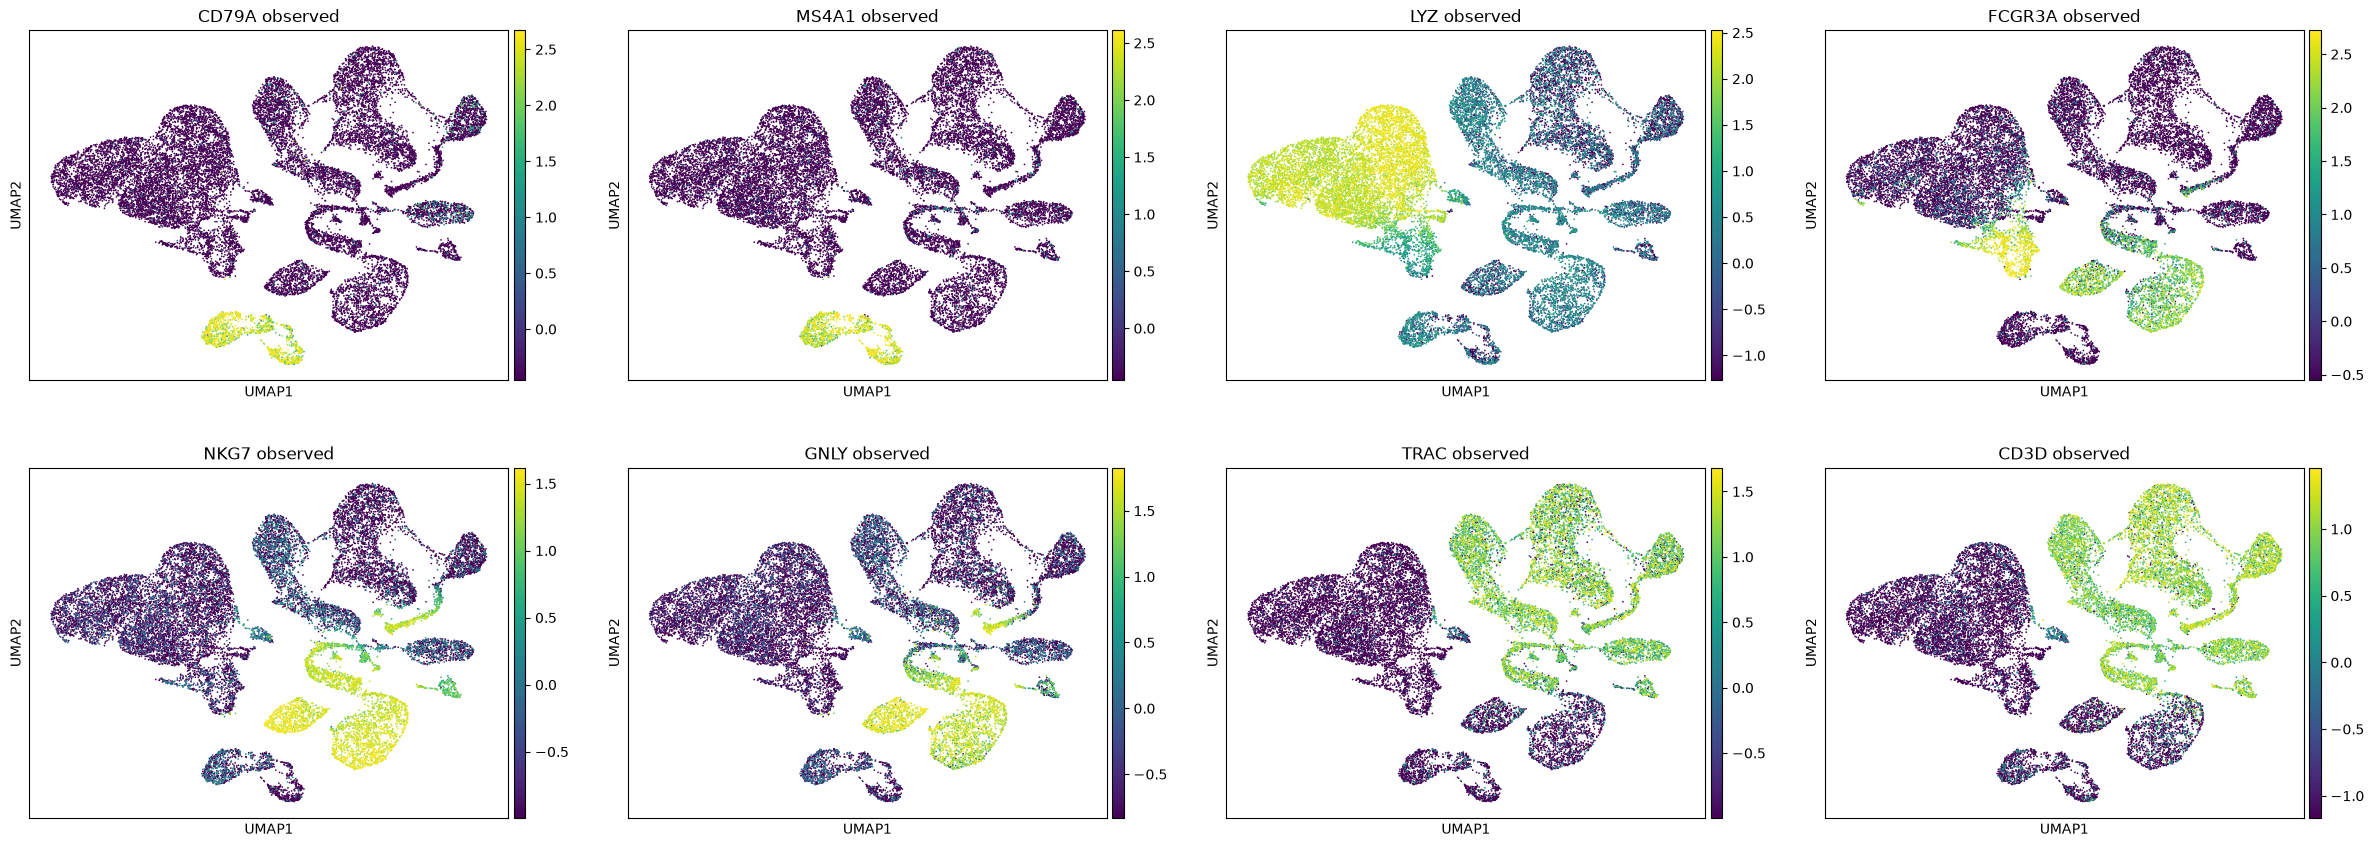

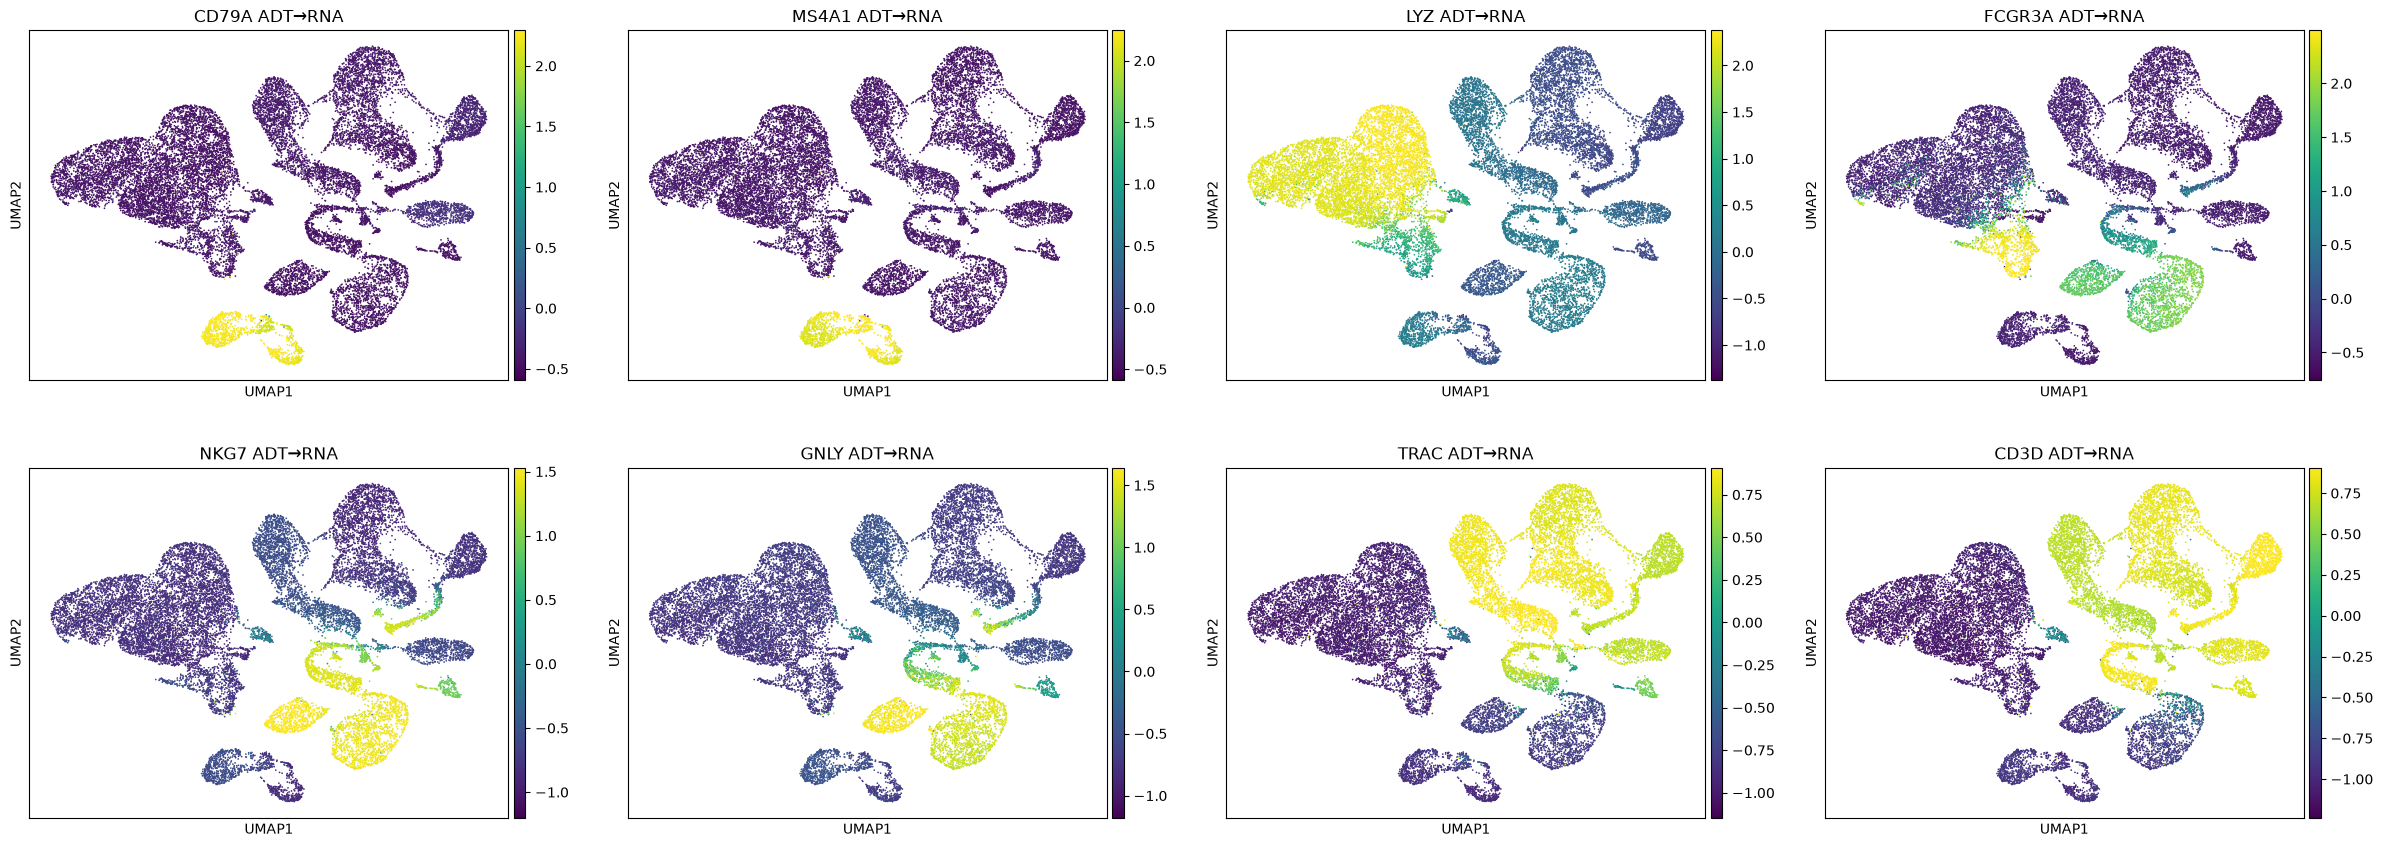

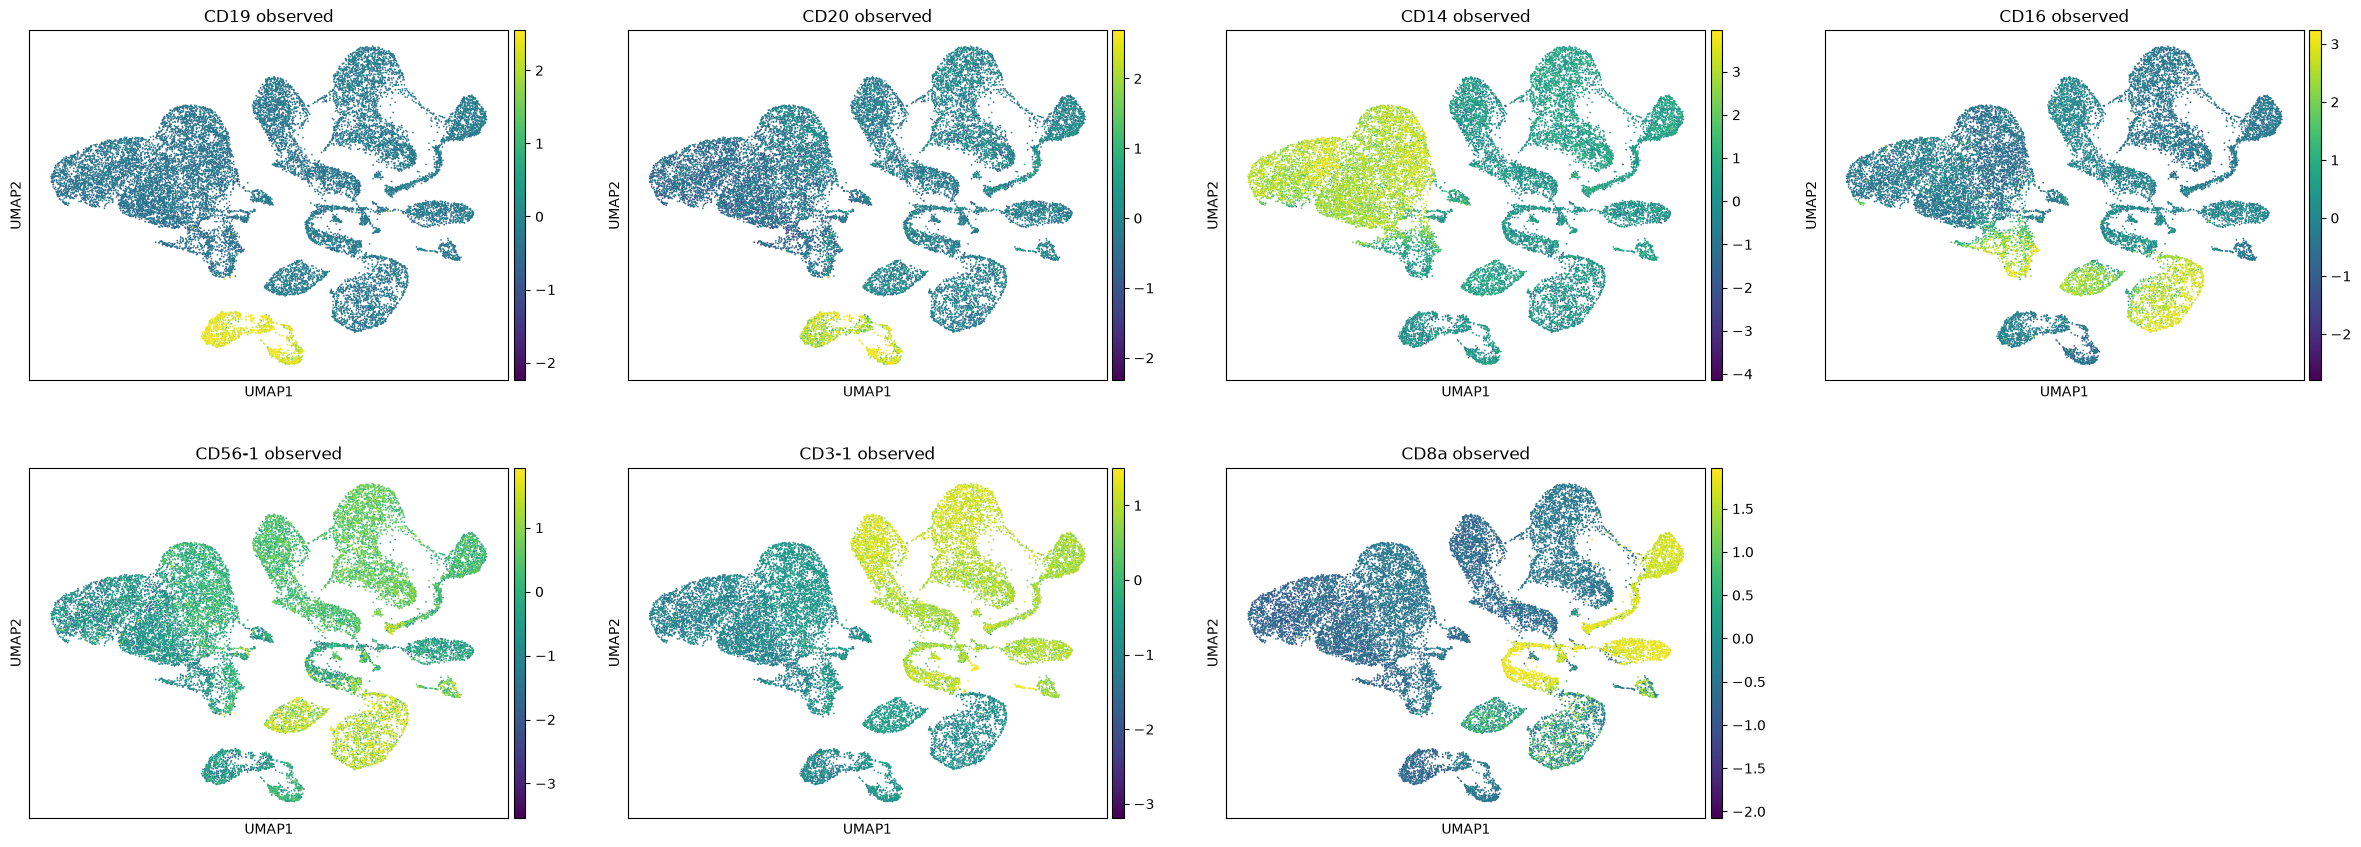

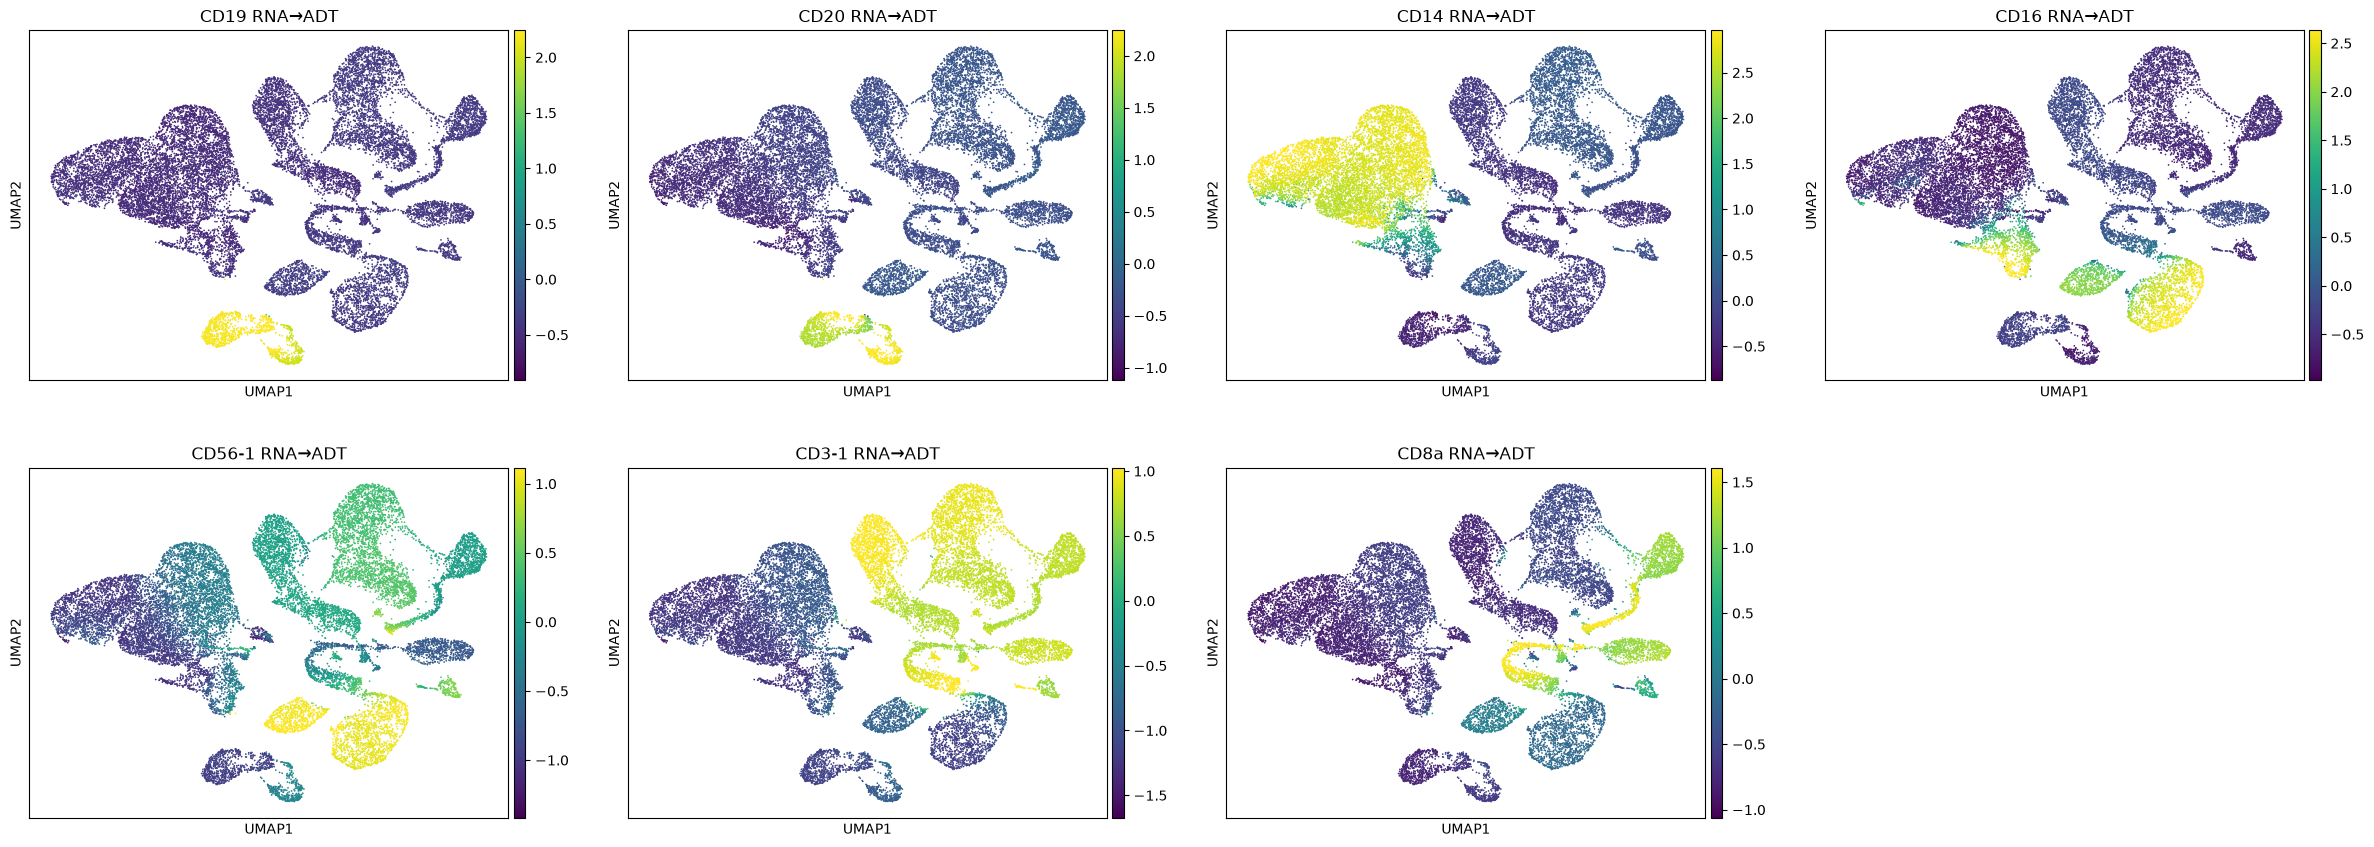

In [9]:
rna_t, adt_t = test["rna"], test["adt"]
adt_t.layers["from_rna"] = cross_modal_predict(model, rna_t, src_mod="rna", tgt_mod="adt", device=device)
rna_t.layers["from_adt"] = cross_modal_predict(model, adt_t, src_mod="adt", tgt_mod="rna", device=device)
rna_t.obsm["X_univi"] = z_rna
sc.pp.neighbors(rna_t, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(rna_t, random_state=0)
adt_t.obsm["X_umap"] = rna_t.obsm["X_umap"]

genes = [g for g in ["CD79A", "MS4A1", "LYZ", "FCGR3A", "NKG7", "GNLY", "TRAC", "CD3D"] if g in rna_t.var_names]
proteins = [p for p in ["CD19", "CD20", "CD14", "CD16", "CD56-1", "CD3-1", "CD4", "CD8a"] if p in adt_t.var_names]
for adata, feats, layer, label in [(rna_t, genes, "from_adt", "ADT→RNA"), (adt_t, proteins, "from_rna", "RNA→ADT")]:
    sc.pl.umap(adata, color=feats, ncols=4, vmax="p99", cmap="viridis", title=[f"{f} observed" for f in feats])
    sc.pl.umap(adata, color=feats, ncols=4, layer=layer, vmax="p99", cmap="viridis",
               title=[f"{f} {label}" for f in feats])

Mean marker values per `celltype.l2` subtype, observed and predicted (Supplemental Fig. S1L–M):

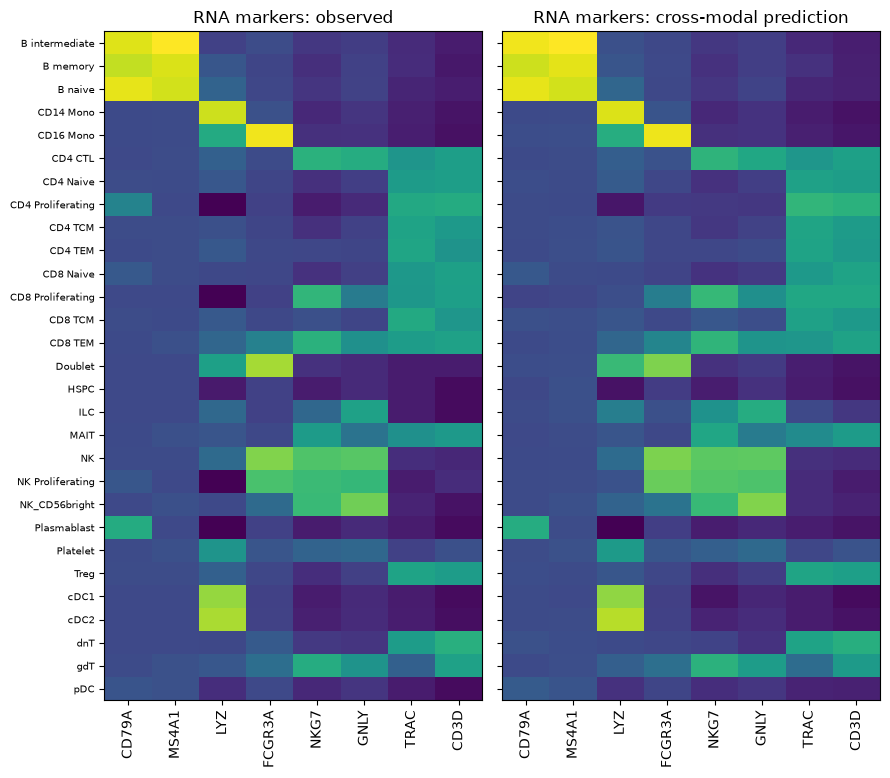

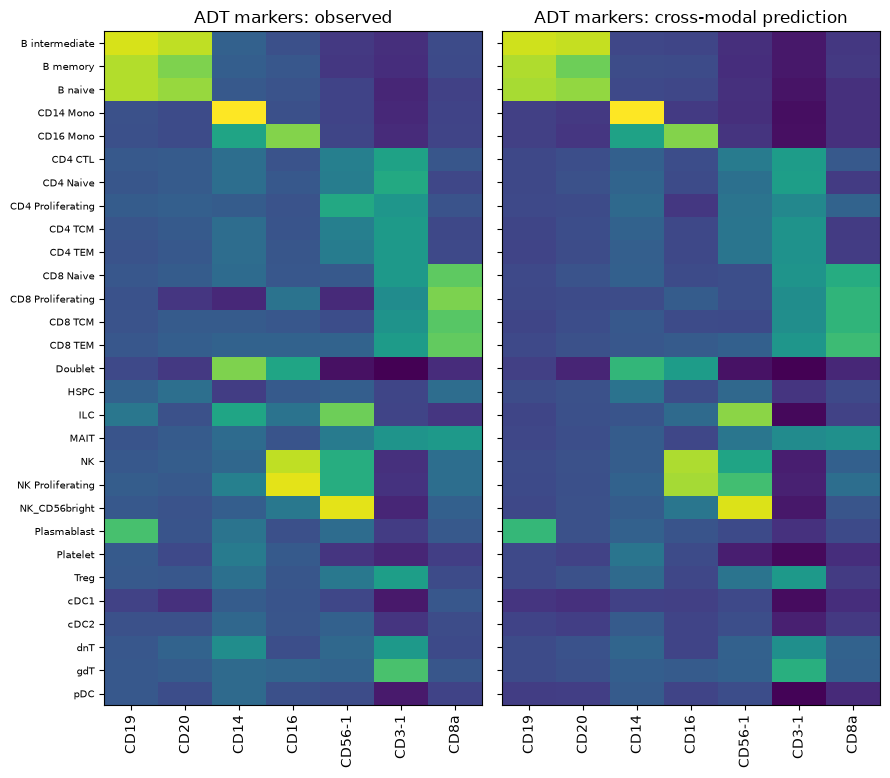

In [10]:
def mean_by_group(adata, feats, layer=None):
    X = adata[:, feats].layers[layer] if layer else adata[:, feats].X
    X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
    return pd.DataFrame(X, columns=feats).groupby(adata.obs["celltype.l2"].astype(str).to_numpy()).mean()

for adata, feats, layer, title in [(rna_t, genes, "from_adt", "RNA markers"), (adt_t, proteins, "from_rna", "ADT markers")]:
    obs_m, pred_m = mean_by_group(adata, feats), mean_by_group(adata, feats, layer)
    fig, axes = plt.subplots(1, 2, figsize=(9, 0.22 * len(obs_m) + 1.5), sharey=True)
    for ax, table, name in zip(axes, [obs_m, pred_m], ["observed", "cross-modal prediction"]):
        ax.imshow(table.values, aspect="auto", cmap="viridis")
        ax.set_xticks(range(len(feats)), feats, rotation=90)
        ax.set_yticks(range(len(table)), table.index, fontsize=7)
        ax.set_title(f"{title}: {name}")
    plt.tight_layout()
    plt.show()

In [11]:
summary = {
    "ADT from RNA, median per-protein r": np.nanmedian(pearson_corr_per_feature(np.asarray(adt_t.X), adt_t.layers["from_rna"])),
    "RNA from ADT, median per-gene r": np.nanmedian(pearson_corr_per_feature(np.asarray(rna_t.X), rna_t.layers["from_adt"])),
}
pd.Series(summary).round(3)

ADT from RNA, median per-protein r    0.531
RNA from ADT, median per-gene r       0.301
dtype: float32